<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/06_Airbnb_Berlin_Model_Selection_Finetuning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install missingno
# !pip install geopy
# !pip install xgboost

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_Model_Selection = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Model_Selection.pkl')
df_Model_Selection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23460 entries, 0 to 23459
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23460 non-null  float64
 1   Checkin Rating         23460 non-null  float64
 2   Cleanliness Rating     23460 non-null  float64
 3   Communication Rating   23460 non-null  float64
 4   Location Rating        23460 non-null  float64
 5   Overall Rating         23460 non-null  float64
 6   Value Rating           23460 non-null  float64
 7   Host Response Time     23460 non-null  int64  
 8   Is Superhost           23460 non-null  bool   
 9   Neighborhood Group     23460 non-null  int64  
 10  Room Type              23460 non-null  int64  
 11  Accomodates            23460 non-null  float64
 12  Bedrooms               23460 non-null  float64
 13  Beds                   23460 non-null  float64
 14  Guests Included        23460 non-null  float64
 15  Mi

In [ ]:
df = df_Model_Selection.copy()
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]

# Model Selection and Fine Tuning

## Metrics

We reached this stage with only the most important feature bases on 3 out of 4 models (Review Feature Selection stage )

In [ ]:
df.head()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Room Type,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
0,10.0,10.0,10.0,10.0,9.0,100.0,10.0,2,False,6,1,2.000000,1.0,1.0,1.0,2.000000,7.0,0,0,5.1,17,17.0
1,9.0,9.0,9.0,9.0,10.0,92.0,9.0,2,False,6,0,4.000000,1.0,2.0,2.0,1.727273,144.0,0,0,3.7,17,90.0
2,10.0,10.0,10.0,10.0,10.0,96.0,10.0,4,True,6,1,2.000000,1.0,2.0,1.0,2.000000,229.0,0,0,4.6,16,33.0
3,10.0,10.0,10.0,10.0,10.0,100.0,10.0,2,False,6,0,3.636364,4.0,7.0,5.0,6.000000,6.0,0,0,3.5,16,180.0
4,10.0,9.0,10.0,10.0,9.0,93.0,9.0,2,False,6,0,1.000000,0.0,1.0,1.0,2.454545,23.0,0,0,5.0,16,70.0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accuracy Rating,23460.0,9.661056,0.681412,2.0,9.454545,10.000000,10.0,10.0
Checkin Rating,23460.0,9.709451,0.646322,2.0,9.636364,10.000000,10.0,10.0
Cleanliness Rating,23460.0,9.319383,0.949552,2.0,9.000000,9.636364,10.0,10.0
Communication Rating,23460.0,9.729861,0.630342,2.0,9.818182,10.000000,10.0,10.0
Location Rating,23460.0,9.531140,0.692394,2.0,9.000000,10.000000,10.0,10.0
Overall Rating,23460.0,94.594094,6.965420,20.0,92.727273,96.363636,100.0,100.0
Value Rating,23460.0,9.397617,0.776198,2.0,9.000000,9.636364,10.0,10.0
Host Response Time,23460.0,2.208483,1.332796,0.0,1.000000,2.000000,4.0,4.0
Neighborhood Group,23460.0,4.130264,2.939809,0.0,1.000000,4.000000,6.0,11.0
Room Type,23460.0,0.523444,0.525334,0.0,0.000000,1.000000,1.0,2.0


In [ ]:
df.corr()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Room Type,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
Accuracy Rating,1.000000,0.498351,0.520678,0.525840,0.372890,0.659653,0.592685,0.053669,0.158628,0.013369,-0.023680,-0.010399,-0.002186,-0.061392,-0.005532,0.058769,0.075653,-0.008973,-0.018814,-0.012565,0.033809,0.025099
Checkin Rating,0.498351,1.000000,0.378032,0.616875,0.314393,0.507937,0.438302,0.070134,0.135942,0.016577,-0.001012,-0.004191,0.017978,-0.013341,0.015905,0.027123,0.070782,0.018731,-0.013951,0.012356,0.023976,0.030650
Cleanliness Rating,0.520678,0.378032,1.000000,0.402481,0.299935,0.669478,0.524189,0.114043,0.191876,0.026025,-0.061700,0.007768,0.031630,-0.005625,0.030942,0.013235,0.091989,0.044201,-0.015866,0.015238,0.040588,0.113215
Communication Rating,0.525840,0.616875,0.402481,1.000000,0.340384,0.574122,0.482978,0.060430,0.138034,0.016602,-0.013126,-0.000944,0.011096,-0.030370,0.005683,0.033131,0.057914,-0.007836,-0.012971,-0.005969,0.042086,0.025143
Location Rating,0.372890,0.314393,0.299935,0.340384,1.000000,0.408543,0.415479,0.082921,0.105315,-0.064840,-0.031348,0.001034,-0.008889,-0.054444,-0.008849,0.041208,0.074216,-0.039651,-0.117988,-0.186916,0.031461,0.084842
Overall Rating,0.659653,0.507937,0.669478,0.574122,0.408543,1.000000,0.680576,0.023242,0.155509,0.014780,-0.014266,-0.030394,0.005598,-0.071520,-0.017757,0.066790,-0.001643,-0.000081,-0.015576,-0.012634,0.020368,0.051669
Value Rating,0.592685,0.438302,0.524189,0.482978,0.415479,0.680576,1.000000,-0.002451,0.128992,0.022772,0.071277,-0.076636,-0.022019,-0.092517,-0.050659,0.068285,0.017855,-0.022774,0.002976,0.009168,0.009735,-0.067639
Host Response Time,0.053669,0.070134,0.114043,0.060430,0.082921,0.023242,-0.002451,1.000000,0.364287,0.007908,-0.050116,0.122383,0.050126,0.157194,0.149647,-0.114230,0.363463,0.156290,-0.043496,0.061375,-0.043366,0.159898
Is Superhost,0.158628,0.135942,0.191876,0.138034,0.105315,0.155509,0.128992,0.364287,1.000000,0.013718,-0.006998,0.034418,0.032250,0.035141,0.084895,-0.060504,0.355657,0.083164,-0.035393,0.014861,0.050029,0.083564
Neighborhood Group,0.013369,0.016577,0.026025,0.016602,-0.064840,0.014780,0.022772,0.007908,0.013718,1.000000,-0.018953,0.013964,0.035156,0.036803,0.003398,0.011761,-0.008676,0.040586,0.143318,0.300516,-0.011890,-0.036915


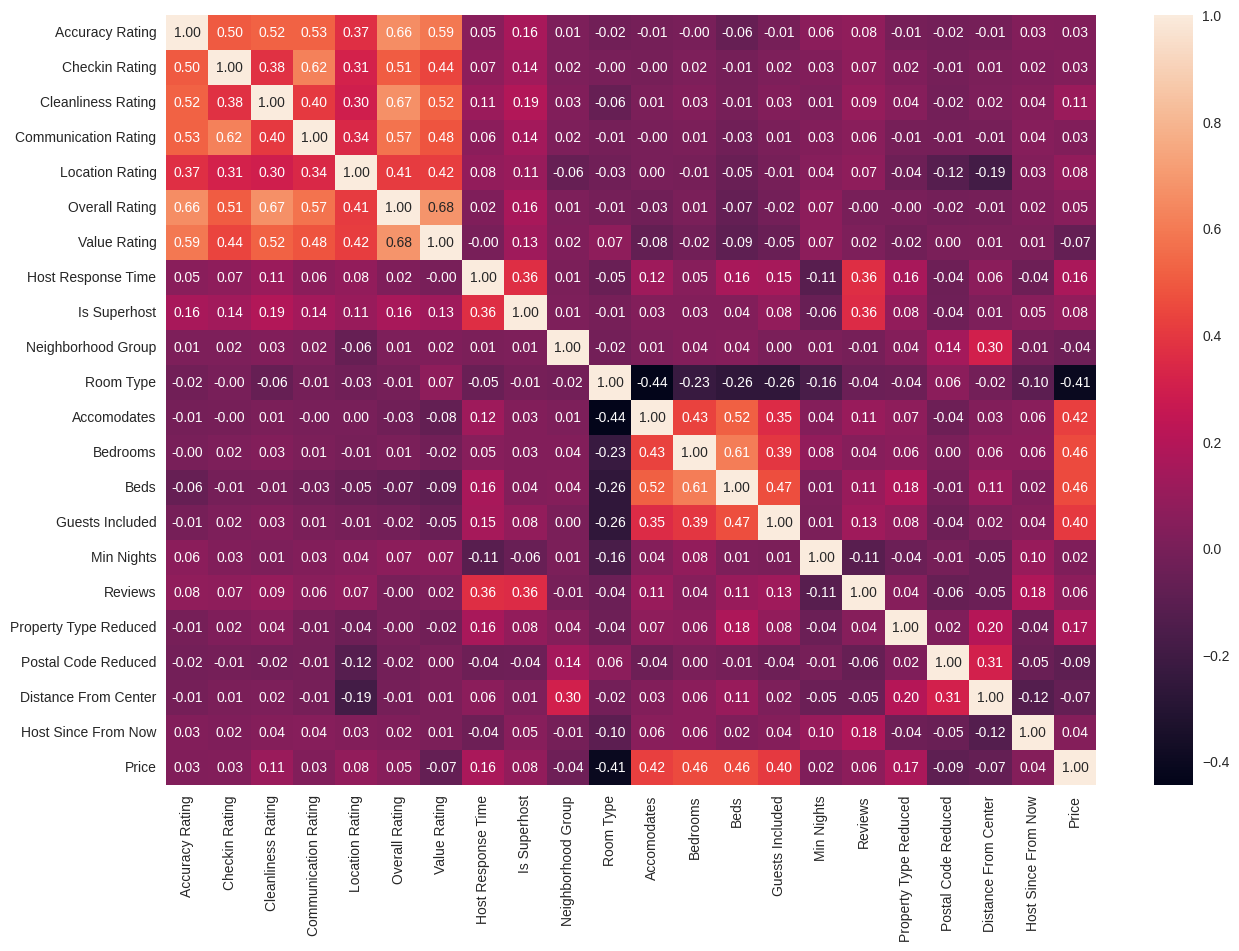

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", annot_kws={"size":10})
plt.show()

## Create and Train the Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import sklearn.metrics as metrics

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Price', inplace=False)
y = df['Price']

# Split into train+val and test sets (80% train+val, 20% test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split train+val into train and val sets (75% train, 25% val from the train+val set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

## Regression Models

In [ ]:
models_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])
models_list.style.set_properties(subset=['model'], **{'text-align': 'left'})

,model,MAE,MSE,RMSE,RMSLE,R²


In [ ]:
def regressionMetrics(y, y_pred):
    res = {
          'MAE': metrics.mean_absolute_error(y, y_pred),
          'MSE': metrics.mean_squared_error(y, y_pred),
          'RMSE': np.sqrt(metrics.mean_squared_error(y, y_pred)),
          'RMSLE': np.sqrt(metrics.mean_squared_log_error(np.abs(y), np.abs(y_pred))),
          'R²': metrics.r2_score(y, y_pred)
          }

    return res

### Linear Regression

In [ ]:
# create and train model
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

LinearRegression()

In [ ]:
# make predictions on the validation set
y_val_pred_LR = model_LR.predict(X_val)

In [ ]:
regressionMetrics(y_val, y_val_pred_LR)

{'MAE': 21.971827891070312,
 'MSE': 1400.236775960054,
 'RMSE': np.float64(37.41973778582707),
 'RMSLE': np.float64(0.4786325096052562),
 'R²': 0.41346010104859776}

In [ ]:
model_dict = {"model":"LinearRegression"}
model_dict.update(regressionMetrics(y_val, y_val_pred_LR))
model_dict
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)

In [ ]:
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.41346


<Axes: xlabel='Price'>

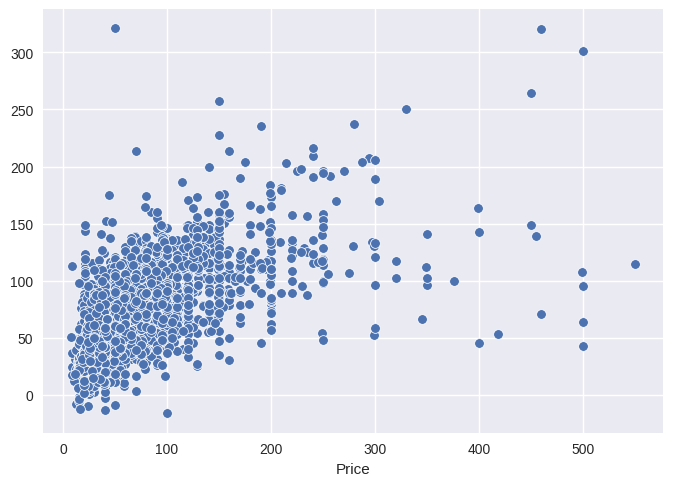

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_LR)

### Decision Tree Regressor

In [ ]:
model_DTR = DecisionTreeRegressor(random_state=42)
model_DTR.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# make predictions on the validation set
y_val_pred_DTR = model_DTR.predict(X_val)

In [ ]:
regressionMetrics(y_val, y_val_pred_DTR)

{'MAE': 27.106351236146633,
 'MSE': 2433.8211849957374,
 'RMSE': np.float64(49.3337732693916),
 'RMSLE': np.float64(0.5430771751293749),
 'R²': -0.01949417157281297}

In [ ]:
model_dict = {"model":"DecisionTree"}
model_dict.update(regressionMetrics(y_val, y_val_pred_DTR))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
# models_list.style.set_properties(**{'text-align': 'left'})
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494


<Axes: xlabel='Price'>

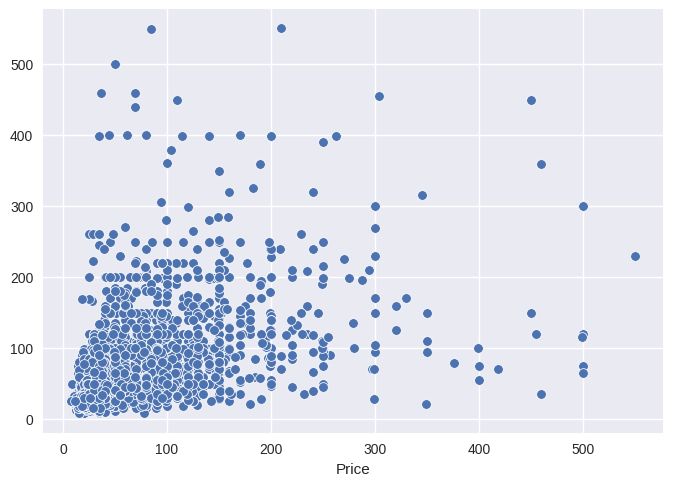

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_DTR)

### Random Forest Regressor

In [ ]:
model_RFR = RandomForestRegressor(random_state=42)
model_RFR.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions on the validation set
y_val_pred_RFR = model_RFR.predict(X_val)

In [ ]:
regressionMetrics(y_val, y_val_pred_RFR)

{'MAE': 19.812008915885194,
 'MSE': 1168.1901131190973,
 'RMSE': np.float64(34.1787962502938),
 'RMSLE': np.float64(0.40758820378728144),
 'R²': 0.5106612519621113}

In [ ]:
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_RFR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661


<Axes: xlabel='Price'>

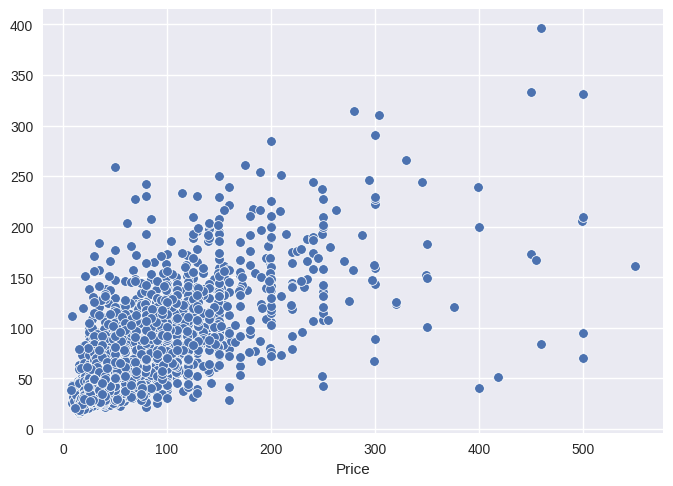

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_RFR)

### Adaptive Boosting (ADABoost)

In [ ]:
model_ADABoost = AdaBoostRegressor(random_state=42)
model_ADABoost.fit(X_train, y_train)

AdaBoostRegressor(random_state=42)

In [ ]:
# Make predictions on the validation set
y_val_pred_ADABoost = model_ADABoost.predict(X_val)

In [ ]:
regressionMetrics(y_val, y_val_pred_ADABoost)

{'MAE': 29.510711011003277,
 'MSE': 1953.066810011893,
 'RMSE': np.float64(44.19351547469259),
 'RMSLE': np.float64(0.5655738525126497),
 'R²': 0.1818872143218202}

Update model list with **Adaptive Boosting (ADABoost)** model results

In [ ]:
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_ADABoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887


<Axes: xlabel='Price'>

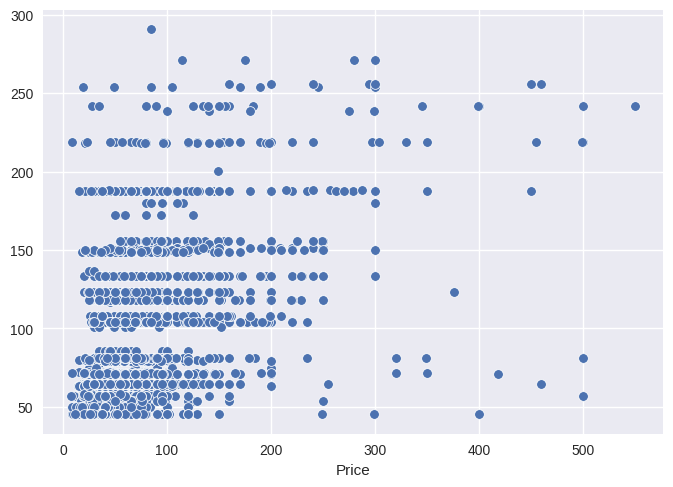

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_ADABoost)

### Gradient Boosting Machine (GBM)

In [ ]:
model_GBM = GradientBoostingRegressor(random_state=42)
model_GBM.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# Make predictions on the validation set
y_val_pred_GBM = model_GBM.predict(X_val)

In [ ]:
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_GBM)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887
4,GBM,19.392612,1110.113461,33.318365,0.399651,0.534989


<Axes: xlabel='Price'>

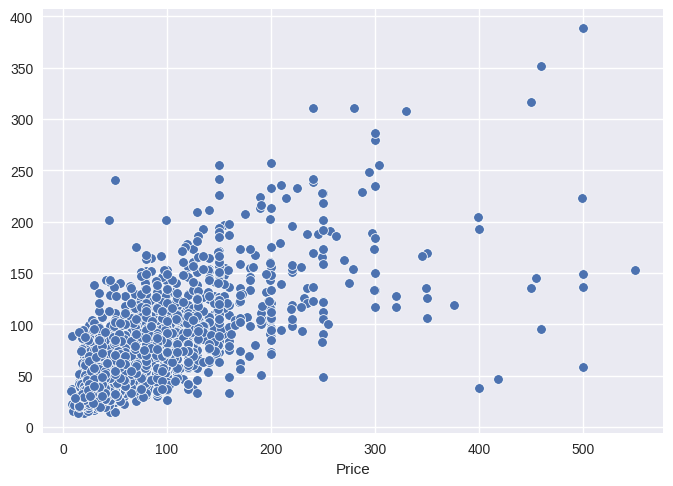

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_GBM)

### Support Vector Machine (SVM)

In [ ]:
model_SVR = SVR()
model_SVR.fit(X_train, y_train)

SVR()

In [ ]:
# Make predictions on the validation set
y_val_pred_SVR = model_SVR.predict(X_val)

In [ ]:
regressionMetrics(y_val,y_val_pred_SVR)

{'MAE': 27.609842911524055,
 'MSE': 2393.708543105806,
 'RMSE': np.float64(48.92554080545054),
 'RMSLE': np.float64(0.561254215762587),
 'R²': -0.002691538386248693}

In [ ]:
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_SVR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887
4,GBM,19.392612,1110.113461,33.318365,0.399651,0.534989
5,SVM,27.609843,2393.708543,48.925541,0.561254,-0.002692


<Axes: xlabel='Price'>

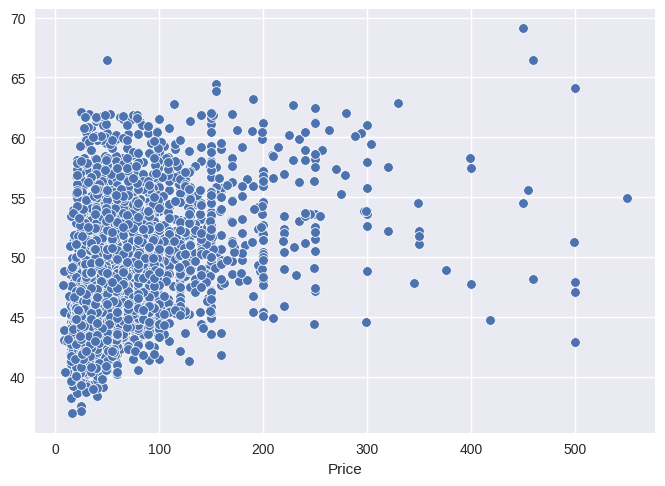

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_SVR)

### XGBoost Regressor

In [ ]:
model_XGBoost= xgb.XGBRegressor()
model_XGBoost.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred_XGBoost = model_XGBoost.predict(X_val)

In [ ]:
regressionMetrics(y_val,y_val_pred_XGBoost)

{'MAE': 19.088835330875327,
 'MSE': 1058.989012205217,
 'RMSE': np.float64(32.54211136673859),
 'RMSLE': np.float64(0.3976261491262454),
 'R²': 0.5564040890272881}

In [ ]:
model_dict = {'model': "XGBoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_XGBoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887
4,GBM,19.392612,1110.113461,33.318365,0.399651,0.534989
5,SVM,27.609843,2393.708543,48.925541,0.561254,-0.002692
6,XGBoost,19.088835,1058.989012,32.542111,0.397626,0.556404


<Axes: xlabel='Price'>

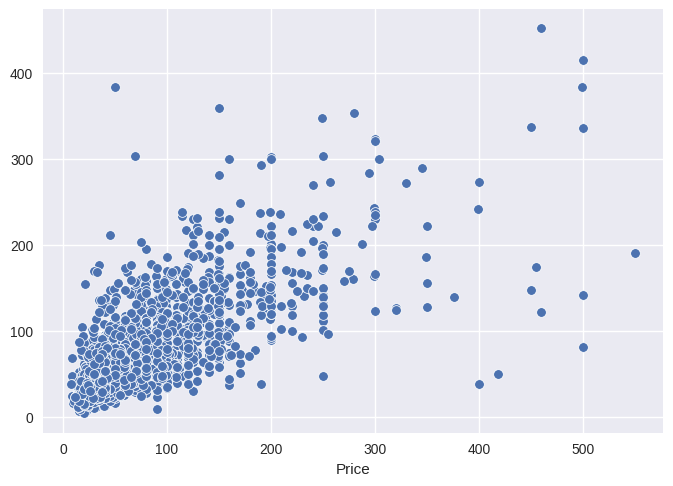

In [ ]:
sns.scatterplot(x=y_val, y=y_val_pred_XGBoost)

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [ ]:
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
6,XGBoost,19.088835,1058.989012,32.542111,0.397626,0.556404
4,GBM,19.392612,1110.113461,33.318365,0.399651,0.534989
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
5,SVM,27.609843,2393.708543,48.925541,0.561254,-0.002692
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887


## Hyperparameters and Finetuning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

### Random Search: we decide which parameters and how (randomly)

In [ ]:
%matplotlib inline

# Reduced number of options for each hyperparameter
n_estimators = [100, 200, 300]  # Fewer values for the number of trees
max_features = ['auto','sqrt']  #  # Number of features to consider at each split
max_depth = [10, 20, 30, 40, None]  # Fewer values for max depth
min_samples_split = [2, 5, 10]  # Keep essential options only
min_samples_leaf = [1, 2, 4]  # Reduced options for leaf samples
bootstrap = [True, False]  # Keep as is

# Create a lighter random grid
lighter_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(lighter_grid)
rf_random = RandomizedSearchCV(estimator=model_RFR, param_distributions=lighter_grid, n_iter=25, cv=3,
                               verbose=2, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

{'n_estimators': [100, 200, 300], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}
Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

In [ ]:
rf_random.best_estimator_

RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_split=5, n_estimators=300, random_state=42)

In [ ]:
def evaluate(model, test_features, y_test):
    predictions = model.predict(test_features)
    errors = abs(predictions - y_test)
    mae = 100 * np.mean(errors)
    print('Model Performance')
    print('Mean Absolute Error: {:0.4f}'.format(np.mean(errors)))
    # print('R^2: {:0.2f}'.format(metrics.r2_score(predictions, y_test)))
    return mae

#### Running base Model

In [ ]:
base_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_val, y_val)

Model Performance
Mean Absolute Error: 19.8120


In [ ]:
best_random = rf_random.best_estimator_
random_accuracy = evaluate(best_random, X_val, y_val)

Model Performance
Mean Absolute Error: 18.4249


#### Comparisson

In [ ]:
print('Improvement of {:0.2f}%.'.format( 100 * (base_accuracy - random_accuracy) / base_accuracy))

Improvement of 7.00%.


Good improvment of 5.52% from the fine tuning when used with **RandomForestRegressor** model, so we can try use the tinued model instead of basic

## Model Evaluation

### Performance Metrics

Performance Metrics with the fine tuned Model

In [ ]:
# make predictions on the validation set
y_val_pred_RFR_best_random = best_random.predict(X_val)

In [ ]:
model_dict = {"model":"RandomForest_Tuned"}
model_dict.update(regressionMetrics(y_val, y_val_pred_RFR_best_random))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,RandomForest_Tuned,18.424892,1038.825276,32.230813,0.384836,0.564850
6,XGBoost,19.088835,1058.989012,32.542111,0.397626,0.556404
4,GBM,19.392612,1110.113461,33.318365,0.399651,0.534989
2,RandomForest,19.812009,1168.190113,34.178796,0.407588,0.510661
0,LinearRegression,21.971828,1400.236776,37.419738,0.478633,0.413460
1,DecisionTree,27.106351,2433.821185,49.333773,0.543077,-0.019494
5,SVM,27.609843,2393.708543,48.925541,0.561254,-0.002692
3,ADABoost,29.510711,1953.066810,44.193515,0.565574,0.181887


After we added the tuned Random Forest Regressor to all metrics table , we can see it is a little better from XGBoost Model

### Validation with X_test, y_test

In [ ]:
models_ = {"LinearRegression":model_LR,
           "DecisionTree":model_DTR,
           "RandomForest":model_RFR,
           "ADABoost":model_ADABoost,
           "GBM":model_GBM,
           "SVR":model_SVR,
           "XGBoost":model_XGBoost,
           "RandomForest_Tuned":best_random
           }
models_eval_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])

In [ ]:
for name, model in models_.items():
    print(model)
    y_test_pred = model.predict(X_test)
    # print(regressionMetrics(y_test, y_test_pred))
    model_dict = {"model":name}
    model_dict.update(regressionMetrics(y_test, y_test_pred))
    new_row = pd.DataFrame([model_dict])
    models_eval_list = pd.concat([models_eval_list, new_row], ignore_index=True)

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(random_state=42)
AdaBoostRegressor(random_state=42)
GradientBoostingRegressor(random_state=42)
SVR()
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)
RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt'

In [ ]:
models_eval_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,RandomForest_Tuned,18.464568,1018.055651,31.906984,0.383515,0.548098
6,XGBoost,18.943212,1072.720485,32.752412,0.391233,0.523833
4,GBM,19.182484,1071.343460,32.731383,0.393951,0.524444
2,RandomForest,19.487438,1103.768108,33.223006,0.402343,0.510051
0,LinearRegression,21.611289,1316.465641,36.283132,0.463381,0.415637
1,DecisionTree,26.788363,2431.391091,49.309138,0.539322,-0.079264
5,SVR,27.265245,2263.359686,47.574780,0.554178,-0.004677
3,ADABoost,28.698045,1793.594578,42.350851,0.552306,0.203846


## Conclusions and best Model selected

From last model list , the best model with best stat measurments with MAE 15.45 and R2 = 0.548 is the tuned RandomForestRegressoer **RandomForest_Tuned**

In [ ]:
RandomForest_Tuned = best_random

In [ ]:
import joblib
joblib.dump(RandomForest_Tuned,"/content/drive/My Drive/Airbnb/RandomForest_Tuned.pkl")

['/content/drive/My Drive/Airbnb/RandomForest_Tuned.pkl']

## Store Objects States

In [ ]:
# import joblib

# joblib.dump(model_LR,"/content/drive/My Drive/Airbnb/model_LR.pkl")
# joblib.dump(model_DTR,"/content/drive/My Drive/Airbnb/model_DTR.pkl")
# joblib.dump(model_RFR,"/content/drive/My Drive/Airbnb/model_RFR.pkl")
# joblib.dump(model_ADABoost,"/content/drive/My Drive/Airbnb/model_ADABoost.pkl")
# joblib.dump(model_GBM,"/content/drive/My Drive/Airbnb/model_GBM.pkl")
# joblib.dump(model_SVR,"/content/drive/My Drive/Airbnb/model_SVR.pkl")
# joblib.dump(model_XGBoost,"/content/drive/My Drive/Airbnb/model_XGBoost.pkl")
# joblib.dump(best_random,"/content/drive/My Drive/Airbnb/best_random.pkl")

models_list.to_pickle("/content/drive/My Drive/Airbnb/models_selection_list.pkl")
df.to_pickle("/content/drive/My Drive/Airbnb/df_Model_Selection_Post.pkl")

In [ ]:
# model_LR_ = joblib.load("/content/drive/My Drive/Airbnb/model_LR.pkl")